# 🎯 Hyperparameter-Optimierung für Help Desk Ticket Prediction

**Zielvariable:** `wf_total_time` (Gesamtbearbeitungszeit)

Dieses Notebook führt eine systematische Hyperparameter-Optimierung durch, basierend auf den Erkenntnissen der explorativen Datenanalyse.

---

## 1. Setup & Installation

In [1]:
# Installation der benötigten Pakete (in Colab)
!pip install -q optuna xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.5 MB/s eta 0:00:00


In [2]:
# Google Drive mounten (für Colab)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [38]:
# Imports
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import json
import pickle

from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import optuna
from optuna.samplers import TPESampler
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("✓ Alle Pakete geladen!")

✓ Alle Pakete geladen!


## 2. Konfiguration

⚠️ **Passen Sie den Pfad an Ihre Umgebung an!**

In [39]:
# =============================================================================
# KONFIGURATION - BITTE ANPASSEN!
# =============================================================================

class Config:
    # Pfad zu den Daten
    #DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/nov25_bds_int_helpdesk/data/raw')
    
    #Chris path
    DATA_DIR = Path('../data/raw')
    #dfi = pd.read_csv('../data/raw/issues.csv')
    #dfs = pd.read_csv('../data/raw/issues_snapshot.csv')
    #dfu = pd.read_csv('../data/raw/sample_utterances.csv')
    #dfrate = pd.read_excel('../data/raw/issues_snapshot_sample.xlsx')
    #dfch = pd.read_csv('../data/raw/issues_change_history.csv')

    # Zufallsseed
    RANDOM_STATE = 42

    # Zielvariable
    TARGET = 'wf_total_time'

    # Zeitlicher Cutoff (Drift vor 2017 laut EDA)
    CUTOFF_DATE = '2017-01-01'

    # Test-Split
    TEST_SIZE = 0.2

    # Cross-Validation Folds
    CV_FOLDS = 5

    # Optuna Einstellungen
    N_TRIALS = 300          # Erhöhen für bessere Ergebnisse (z.B. 100-200)
    TIMEOUT = 5400         # 30 Minuten pro Modell

    # Feature-Listen
    NUMERIC_FEATURES = [
        'issue_contr_count', 'issue_comments_count', 'processing_steps',
        'wf_in_review', 'wf_deployment', 'wf_resolved', 'wf_open',
        'wf_monitoring', 'wf_done', 'wf_pending_customer_approval',
        'wf_rejected', 'wf_testing_monitoring', 'wf_in_progress',
        'wf_reopened', 'wf_to_do', 'wf_validation',
        'wf_resolved_under_monitoring', 'wf_closed', 'wf_waiting',
        'wf_cancelled', 'wf_under_review', 'wf_approved',
        'wf_pending_deployment'
    ]

    CATEGORICAL_FEATURES = [
        'issue_type', 'issue_priority', 'issue_status', 'proj_type'
    ]

config = Config()
print(f"✓ Konfiguration geladen")
print(f"  Daten-Pfad: {config.DATA_DIR}")

✓ Konfiguration geladen
  Daten-Pfad: ../data/raw


## 3. Daten laden und vorbereiten

In [40]:
# Daten laden
df = pd.read_csv(config.DATA_DIR / "issues.csv", low_memory=False)
print(f"✓ Datensatz geladen: {df.shape[0]:,} Zeilen, {df.shape[1]} Spalten")

# Timestamps konvertieren
date_cols = ['started', 'ended', 'issue_created', 'issue_resolution_date', 'last_change_date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format='ISO8601', errors='coerce')

# Zeitlichen Cutoff anwenden
cutoff = pd.Timestamp(config.CUTOFF_DATE, tz='UTC')
if df['issue_created'].dt.tz is None:
    df['issue_created'] = df['issue_created'].dt.tz_localize('UTC')
df = df[df['issue_created'] >= cutoff].copy()
print(f"✓ Nach Filter (ab {config.CUTOFF_DATE}): {df.shape[0]:,} Zeilen")

# Projekt-Typ extrahieren
proj = df['issue_proj'].astype('string').str.strip()
df['proj_type'] = 'internal'
df.loc[proj.str.match(r'^C\d{2}.+', na=False), 'proj_type'] = 'external'

# Issue-Type bereinigen
df['issue_type'] = df['issue_type'].replace({'Sub-task': 'Subtask'})

# Zielvariable filtern
df = df[df[config.TARGET].notna() & (df[config.TARGET] > 0)].copy()
print(f"✓ Nach Bereinigung: {df.shape[0]:,} Zeilen")

✓ Datensatz geladen: 66,691 Zeilen, 58 Spalten
✓ Nach Filter (ab 2017-01-01): 35,921 Zeilen
✓ Nach Bereinigung: 35,844 Zeilen


## 4. Feature Engineering

In [41]:
# Verfügbare Features
available_numeric = [f for f in config.NUMERIC_FEATURES if f in df.columns]
available_categorical = [f for f in config.CATEGORICAL_FEATURES if f in df.columns]

print(f"Numerische Features: {len(available_numeric)}")
print(f"Kategorische Features: {len(available_categorical)}")

# Feature-Matrix
X = df[available_numeric + available_categorical].copy()

# Zielvariable (Log-Transformation!)
y = np.log1p(df[config.TARGET].values)

# Fehlende Werte behandeln
for col in available_numeric:
    X[col] = X[col].fillna(X[col].median())

for col in available_categorical:
    X[col] = X[col].fillna('missing')

# Zusätzliche Features
if 'wf_waiting' in X.columns and 'wf_open' in X.columns:
    X['waiting_to_open_ratio'] = X['wf_waiting'] / (X['wf_open'] + 1)

if 'issue_created' in df.columns:
    X['created_month'] = df['issue_created'].dt.month
    X['created_dayofweek'] = df['issue_created'].dt.dayofweek

# Kategorische Features kodieren
label_encoders = {}
for col in available_categorical:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print(f"\n✓ Feature-Matrix: {X.shape}")
print(f"  Features: {list(X.columns)}")

Numerische Features: 23
Kategorische Features: 4

✓ Feature-Matrix: (35844, 30)
  Features: ['issue_contr_count', 'issue_comments_count', 'processing_steps', 'wf_in_review', 'wf_deployment', 'wf_resolved', 'wf_open', 'wf_monitoring', 'wf_done', 'wf_pending_customer_approval', 'wf_rejected', 'wf_testing_monitoring', 'wf_in_progress', 'wf_reopened', 'wf_to_do', 'wf_validation', 'wf_resolved_under_monitoring', 'wf_closed', 'wf_waiting', 'wf_cancelled', 'wf_under_review', 'wf_approved', 'wf_pending_deployment', 'issue_type', 'issue_priority', 'issue_status', 'proj_type', 'waiting_to_open_ratio', 'created_month', 'created_dayofweek']


## 5. Train/Test Split (zeitbasiert)

In [42]:
# Sortieren nach Zeit
sort_idx = df['issue_created'].argsort()
X_sorted = X.iloc[sort_idx].reset_index(drop=True)
y_sorted = y[sort_idx]

# Split
split_idx = int(len(X_sorted) * (1 - config.TEST_SIZE))
X_train, X_test = X_sorted.iloc[:split_idx], X_sorted.iloc[split_idx:]
y_train, y_test = y_sorted[:split_idx], y_sorted[split_idx:]

print(f"Training: {len(X_train):,} Samples")
print(f"Test:     {len(X_test):,} Samples")

Training: 28,675 Samples
Test:     7,169 Samples


## 6. Baseline-Modelle (Schnelltest)

In [43]:
def evaluate(model, name):
    """Schnelle Evaluation"""
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred)) / 86400
    r2 = r2_score(y_test, y_pred)
    print(f"{name}: MAE = {mae:.2f} Tage, R² = {r2:.4f}")
    return mae

print("Baseline-Modelle (Default-Parameter):\n")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
mae_rf = evaluate(rf, "Random Forest")

# XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
mae_xgb = evaluate(xgb_model, "XGBoost")

# LightGBM
lgb_model = lgb.LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train, y_train)
mae_lgb = evaluate(lgb_model, "LightGBM")

Baseline-Modelle (Default-Parameter):

Random Forest: MAE = 2.21 Tage, R² = 0.9446
XGBoost: MAE = 5.15 Tage, R² = 0.9534
LightGBM: MAE = 2.88 Tage, R² = 0.9687


## 7. Optuna Hyperparameter-Optimierung

⏱️ **Dies kann einige Zeit dauern!** Reduzieren Sie `N_TRIALS` für schnellere Ergebnisse.

In [44]:
def create_objective(model_type):
    """Erstellt Optuna Objective für verschiedene Modelltypen"""

    def objective(trial):
        if model_type == 'xgboost':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 1500),
                'max_depth': trial.suggest_int('max_depth', 3, 12),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 200),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 50.0, log=True),
                'random_state': config.RANDOM_STATE,
                'n_jobs': -1
            }
            model = xgb.XGBRegressor(**params)

        elif model_type == 'lightgbm':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 1500),
                'max_depth': trial.suggest_int('max_depth', 3, 12),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'num_leaves': trial.suggest_int('num_leaves', 20, 150),
                'min_child_samples': trial.suggest_int('min_child_samples', 10, 200),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 50.0, log=True),
                'random_state': config.RANDOM_STATE,
                'n_jobs': -1,
                'verbose': -1
            }
            model = lgb.LGBMRegressor(**params)

        elif model_type == 'catboost':
            params = {
                'iterations': trial.suggest_int('iterations', 100, 1500),
                'depth': trial.suggest_int('depth', 4, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 50.0, log=True),
                'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 200),
                'random_state': config.RANDOM_STATE,
                'verbose': False
            }
            model = cb.CatBoostRegressor(**params)

        # Cross-Validation
        tscv = TimeSeriesSplit(n_splits=config.CV_FOLDS)
        scores = []

        for train_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)
            mae = mean_absolute_error(y_val, y_pred)
            scores.append(mae)

        return np.mean(scores)

    return objective

In [45]:
# Ergebnisse speichern
optimization_results = {}

# Modelle zum Optimieren
models_to_optimize = ['xgboost', 'lightgbm', 'catboost']

### 7.1 XGBoost Optimierung

In [46]:
%%time

print("=" * 50)
print("XGBOOST OPTIMIERUNG")
print("=" * 50)

study_xgb = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=config.RANDOM_STATE)
)

study_xgb.optimize(
    create_objective('xgboost'),
    n_trials=config.N_TRIALS,
    timeout=config.TIMEOUT,
    show_progress_bar=True
)

print(f"\n✓ Beste MAE (CV): {study_xgb.best_value:.4f}")
print(f"\nBeste Parameter:")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")

optimization_results['xgboost'] = {
    'study': study_xgb,
    'best_params': study_xgb.best_params,
    'best_value': study_xgb.best_value
}

XGBOOST OPTIMIERUNG


  0%|          | 0/300 [00:00<?, ?it/s]


✓ Beste MAE (CV): 0.2382

Beste Parameter:
  n_estimators: 1410
  max_depth: 11
  learning_rate: 0.01763862328535917
  min_child_weight: 1
  subsample: 0.6320345426687665
  colsample_bytree: 0.9154649040875943
  reg_alpha: 0.5165672662494336
  reg_lambda: 0.10505407156730806
CPU times: user 1d 5h 37min 28s, sys: 1min 2s, total: 1d 5h 38min 30s
Wall time: 1h 4min 13s


### 7.2 LightGBM Optimierung

In [47]:
%%time

print("=" * 50)
print("LIGHTGBM OPTIMIERUNG")
print("=" * 50)

study_lgb = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=config.RANDOM_STATE)
)

study_lgb.optimize(
    create_objective('lightgbm'),
    n_trials=config.N_TRIALS,
    timeout=config.TIMEOUT,
    show_progress_bar=True
)

print(f"\n✓ Beste MAE (CV): {study_lgb.best_value:.4f}")
print(f"\nBeste Parameter:")
for k, v in study_lgb.best_params.items():
    print(f"  {k}: {v}")

optimization_results['lightgbm'] = {
    'study': study_lgb,
    'best_params': study_lgb.best_params,
    'best_value': study_lgb.best_value
}

LIGHTGBM OPTIMIERUNG


  0%|          | 0/300 [00:00<?, ?it/s]


✓ Beste MAE (CV): 0.2286

Beste Parameter:
  n_estimators: 1362
  max_depth: 12
  learning_rate: 0.04415561351248475
  num_leaves: 57
  min_child_samples: 10
  subsample: 0.7815363206602133
  colsample_bytree: 0.9925307644909127
  reg_alpha: 1.104303180007175e-07
  reg_lambda: 0.02505989068578268
CPU times: user 1d 6h 11min 17s, sys: 1min 12s, total: 1d 6h 12min 29s
Wall time: 1h 4min 54s


### 7.3 CatBoost Optimierung

In [48]:
%%time

print("=" * 50)
print("CATBOOST OPTIMIERUNG")
print("=" * 50)

study_cb = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=config.RANDOM_STATE)
)

study_cb.optimize(
    create_objective('catboost'),
    n_trials=config.N_TRIALS,
    timeout=config.TIMEOUT,
    show_progress_bar=True
)

print(f"\n✓ Beste MAE (CV): {study_cb.best_value:.4f}")
print(f"\nBeste Parameter:")
for k, v in study_cb.best_params.items():
    print(f"  {k}: {v}")

optimization_results['catboost'] = {
    'study': study_cb,
    'best_params': study_cb.best_params,
    'best_value': study_cb.best_value
}

CATBOOST OPTIMIERUNG


  0%|          | 0/300 [00:00<?, ?it/s]


✓ Beste MAE (CV): 0.2256

Beste Parameter:
  iterations: 1478
  depth: 10
  learning_rate: 0.05524031407986826
  l2_leaf_reg: 0.026071580835431495
  min_data_in_leaf: 197
CPU times: user 1d 1min 6s, sys: 11h 5min 41s, total: 1d 11h 6min 48s
Wall time: 1h 31min 11s


## 8. Finale Modelle trainieren und evaluieren

In [49]:
def train_and_evaluate_final(model_type, best_params):
    """Trainiert finales Modell und evaluiert auf Test-Set"""

    if model_type == 'xgboost':
        model = xgb.XGBRegressor(**best_params, random_state=config.RANDOM_STATE, n_jobs=-1)
    elif model_type == 'lightgbm':
        model = lgb.LGBMRegressor(**best_params, random_state=config.RANDOM_STATE, n_jobs=-1, verbose=-1)
    elif model_type == 'catboost':
        model = cb.CatBoostRegressor(**best_params, random_state=config.RANDOM_STATE, verbose=False)

    # Training
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Metriken (Original-Skala in Tagen)
    y_test_days = np.expm1(y_test) / 86400
    y_pred_days = np.expm1(y_pred) / 86400

    mae = mean_absolute_error(y_test_days, y_pred_days)
    medae = np.median(np.abs(y_test_days - y_pred_days))
    rmse = np.sqrt(mean_squared_error(y_test_days, y_pred_days))
    r2 = r2_score(y_test_days, y_pred_days)

    return {
        'model': model,
        'mae': mae,
        'medae': medae,
        'rmse': rmse,
        'r2': r2,
        'y_pred': y_pred_days
    }

In [50]:
# Finale Modelle trainieren
final_results = {}

for model_type, opt_result in optimization_results.items():
    print(f"\nTrainiere {model_type.upper()}...")
    result = train_and_evaluate_final(model_type, opt_result['best_params'])
    final_results[model_type] = result
    print(f"  MAE: {result['mae']:.2f} Tage")
    print(f"  MedAE: {result['medae']:.2f} Tage")
    print(f"  R²: {result['r2']:.4f}")


Trainiere XGBOOST...
  MAE: 2.35 Tage
  MedAE: 0.21 Tage
  R²: 0.9080

Trainiere LIGHTGBM...
  MAE: 2.40 Tage
  MedAE: 0.20 Tage
  R²: 0.8828

Trainiere CATBOOST...
  MAE: 2.39 Tage
  MedAE: 0.26 Tage
  R²: 0.9089


## 9. Ergebnisvergleich

In [51]:
# Vergleichstabelle
comparison = []
for model_type, result in final_results.items():
    comparison.append({
        'Modell': model_type.upper(),
        'MAE (Tage)': round(result['mae'], 2),
        'MedAE (Tage)': round(result['medae'], 2),
        'RMSE (Tage)': round(result['rmse'], 2),
        'R²': round(result['r2'], 4)
    })

comparison_df = pd.DataFrame(comparison).sort_values('MAE (Tage)')
display(comparison_df)

best_model = comparison_df.iloc[0]['Modell']
print(f"\n🏆 Bestes Modell: {best_model}")

,Modell,MAE (Tage),MedAE (Tage),RMSE (Tage),R²
0,XGBOOST,2.35,0.21,10.95,0.9080
2,CATBOOST,2.39,0.26,10.89,0.9089
1,LIGHTGBM,2.40,0.20,12.35,0.8828



🏆 Bestes Modell: XGBOOST


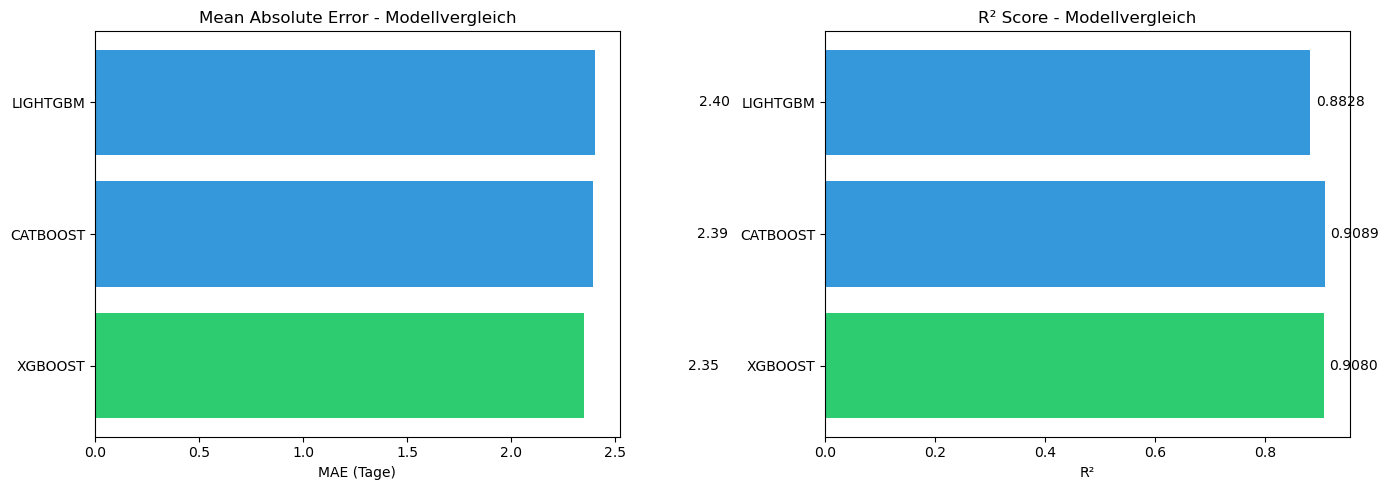

In [52]:
# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE Vergleich
ax1 = axes[0]
colors = ['#2ecc71' if m == best_model else '#3498db' for m in comparison_df['Modell']]
ax1.barh(comparison_df['Modell'], comparison_df['MAE (Tage)'], color=colors)
ax1.set_xlabel('MAE (Tage)')
ax1.set_title('Mean Absolute Error - Modellvergleich')
for i, v in enumerate(comparison_df['MAE (Tage)']):
    ax1.text(v + 0.5, i, f'{v:.2f}', va='center')

# R² Vergleich
ax2 = axes[1]
colors = ['#2ecc71' if m == best_model else '#3498db' for m in comparison_df['Modell']]
ax2.barh(comparison_df['Modell'], comparison_df['R²'], color=colors)
ax2.set_xlabel('R²')
ax2.set_title('R² Score - Modellvergleich')
for i, v in enumerate(comparison_df['R²']):
    ax2.text(v + 0.01, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 10. Feature Importance

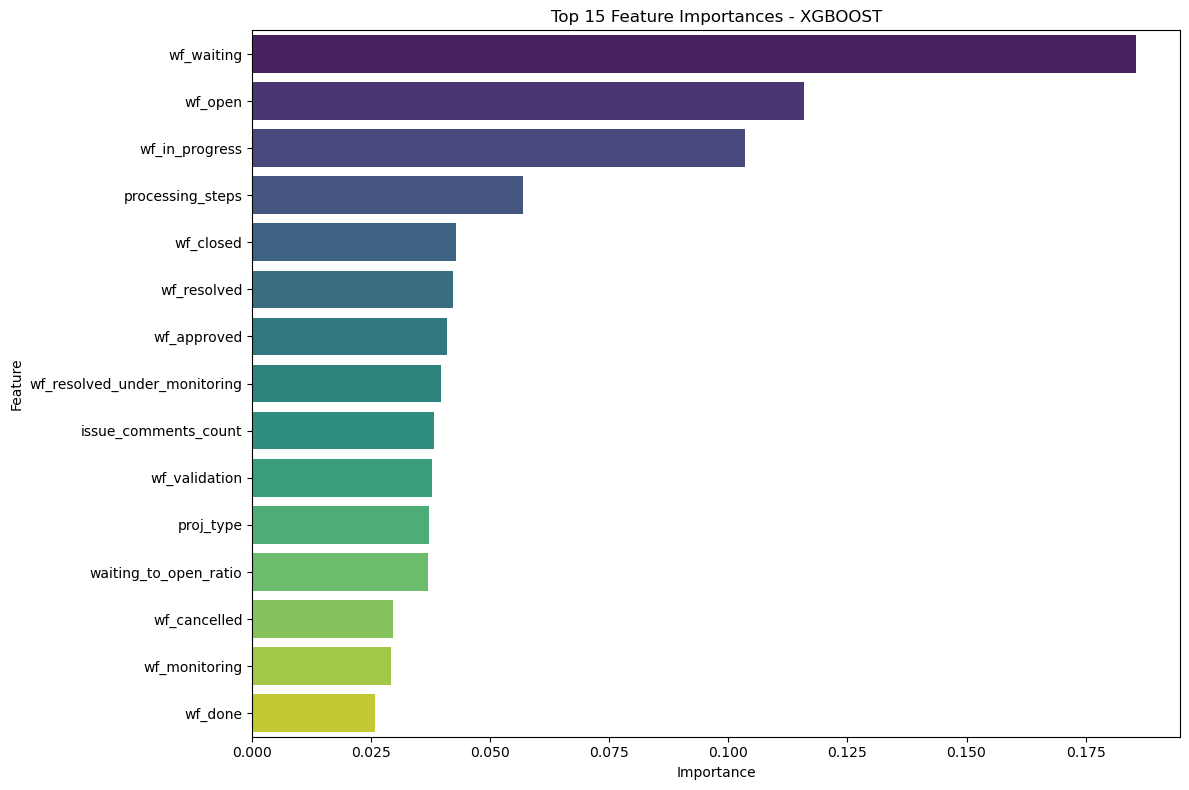


Top 10 Features:


,Feature,Importance
18,wf_waiting,0.185552
6,wf_open,0.115860
12,wf_in_progress,0.103413
2,processing_steps,0.056847
17,wf_closed,0.042870
5,wf_resolved,0.042170
21,wf_approved,0.040845
16,wf_resolved_under_monitoring,0.039572
1,issue_comments_count,0.038106
15,wf_validation,0.037710


In [53]:
# Feature Importance des besten Modells
best_model_name = comparison_df.iloc[0]['Modell'].lower()
best_model_obj = final_results[best_model_name]['model']

# Importance extrahieren
if hasattr(best_model_obj, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model_obj.feature_importances_
    }).sort_values('Importance', ascending=False)

    # Plot
    plt.figure(figsize=(12, 8))
    sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
    plt.title(f'Top 15 Feature Importances - {best_model_name.upper()}')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()

    print("\nTop 10 Features:")
    display(importance_df.head(10))

## 11. Optuna Visualisierungen

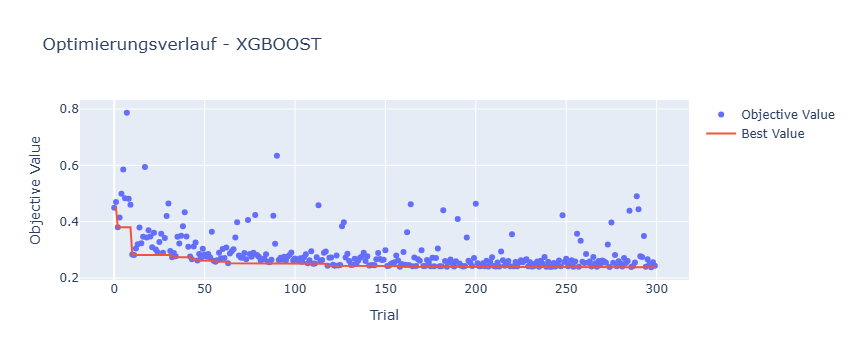

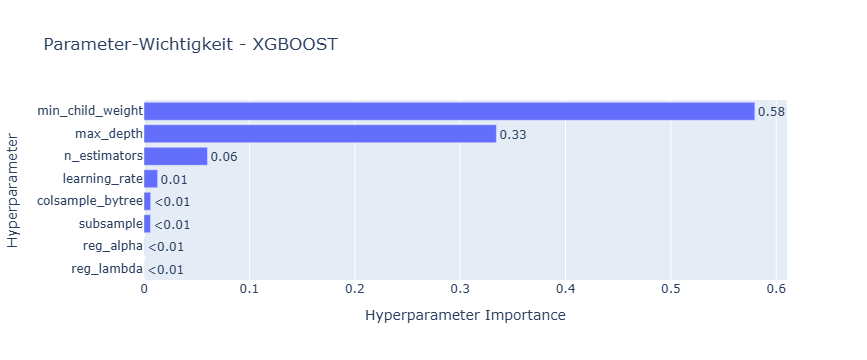

In [54]:
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate
)

# Für das beste Modell
best_study = optimization_results[best_model_name]['study']

# Optimierungsverlauf
fig = plot_optimization_history(best_study)
fig.update_layout(title=f'Optimierungsverlauf - {best_model_name.upper()}')
fig.show()

# Parameter-Wichtigkeit
fig = plot_param_importances(best_study)
fig.update_layout(title=f'Parameter-Wichtigkeit - {best_model_name.upper()}')
fig.show()

## 12. Beste Parameter exportieren

In [55]:
# Alle besten Parameter als JSON
export_data = {}
for model_type, opt_result in optimization_results.items():
    export_data[model_type] = {
        'best_params': opt_result['best_params'],
        'cv_mae': opt_result['best_value'],
        'test_mae': final_results[model_type]['mae'],
        'test_r2': final_results[model_type]['r2']
    }

# Speichern
with open('best_hyperparameters.json', 'w') as f:
    json.dump(export_data, f, indent=2, default=str)

print("✓ Parameter gespeichert in: best_hyperparameters.json")
print("\nInhalt:")
print(json.dumps(export_data, indent=2, default=str))

✓ Parameter gespeichert in: best_hyperparameters.json

Inhalt:
{
  "xgboost": {
    "best_params": {
      "n_estimators": 1410,
      "max_depth": 11,
      "learning_rate": 0.01763862328535917,
      "min_child_weight": 1,
      "subsample": 0.6320345426687665,
      "colsample_bytree": 0.9154649040875943,
      "reg_alpha": 0.5165672662494336,
      "reg_lambda": 0.10505407156730806
    },
    "cv_mae": 0.23821129199303517,
    "test_mae": 2.3498581421551563,
    "test_r2": 0.9079648079366316
  },
  "lightgbm": {
    "best_params": {
      "n_estimators": 1362,
      "max_depth": 12,
      "learning_rate": 0.04415561351248475,
      "num_leaves": 57,
      "min_child_samples": 10,
      "subsample": 0.7815363206602133,
      "colsample_bytree": 0.9925307644909127,
      "reg_alpha": 1.104303180007175e-07,
      "reg_lambda": 0.02505989068578268
    },
    "cv_mae": 0.22855695854770955,
    "test_mae": 2.3991632779145853,
    "test_r2": 0.882823865434772
  },
  "catboost": {
    "bes

In [56]:
# Bestes Modell als Pickle speichern
with open(f'best_model_{best_model_name}.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)

print(f"✓ Modell gespeichert in: best_model_{best_model_name}.pkl")

✓ Modell gespeichert in: best_model_xgboost.pkl


## 13. Zusammenfassung

Die Hyperparameter-Optimierung ist abgeschlossen!

### Nächste Schritte:
1. **Early Stopping** hinzufügen für noch bessere Generalisierung
2. **Feature Selection** basierend auf Importance durchführen
3. **Ensemble-Methoden** (Stacking/Blending) testen
4. **Mehr Trials** laufen lassen (N_TRIALS erhöhen)

In [57]:
print("\n" + "=" * 60)
print("   HYPERPARAMETER-OPTIMIERUNG ABGESCHLOSSEN")
print("=" * 60)
print(f"\n🏆 Bestes Modell: {best_model}")
print(f"   MAE: {comparison_df.iloc[0]['MAE (Tage)']:.2f} Tage")
print(f"   R²:  {comparison_df.iloc[0]['R²']:.4f}")
print("\n" + "=" * 60)


   HYPERPARAMETER-OPTIMIERUNG ABGESCHLOSSEN

🏆 Bestes Modell: XGBOOST
   MAE: 2.35 Tage
   R²:  0.9080

